# Phase I — Unsupervised Structural Analysis
## Bank Marketing Dataset — ML Lab Project 

**Authors:** Arman Bazarchi, Ines Maria Madeira Prates

---

**Prerequisites:** Run `preprocessing.ipynb` first to generate the processed data in `data/`.

### Outline
1. Load Processed Data
2. PCA — Principal Component Analysis
3. Clustering — K-Means & GMM
4. Cluster–Target Alignment Analysis
5. Summary & Discussion

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples

warnings.filterwarnings('ignore')
np.random.seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

---
## 1. Load Processed Data

In [2]:
X_scaled_df = pd.read_csv('data/X_scaled.csv')
y = pd.read_csv('data/y.csv')['y']
df_processed = pd.read_csv('data/df_processed.csv')
df_raw = pd.read_csv('data/df_raw.csv')
feature_names = X_scaled_df.columns.tolist()

X_scaled = X_scaled_df.values

print(f"Feature matrix: {X_scaled.shape}")
print(f"Target: {y.shape[0]} samples, {y.sum()} positive ({y.mean()*100:.1f}%)")
print(f"Number of features: {len(feature_names)}")

Feature matrix: (41188, 15)
Target: 41188 samples, 4640 positive (11.3%)
Number of features: 15


---
## 2. PCA — Principal Component Analysis

### 2.1 Full PCA — Explained Variance Analysis

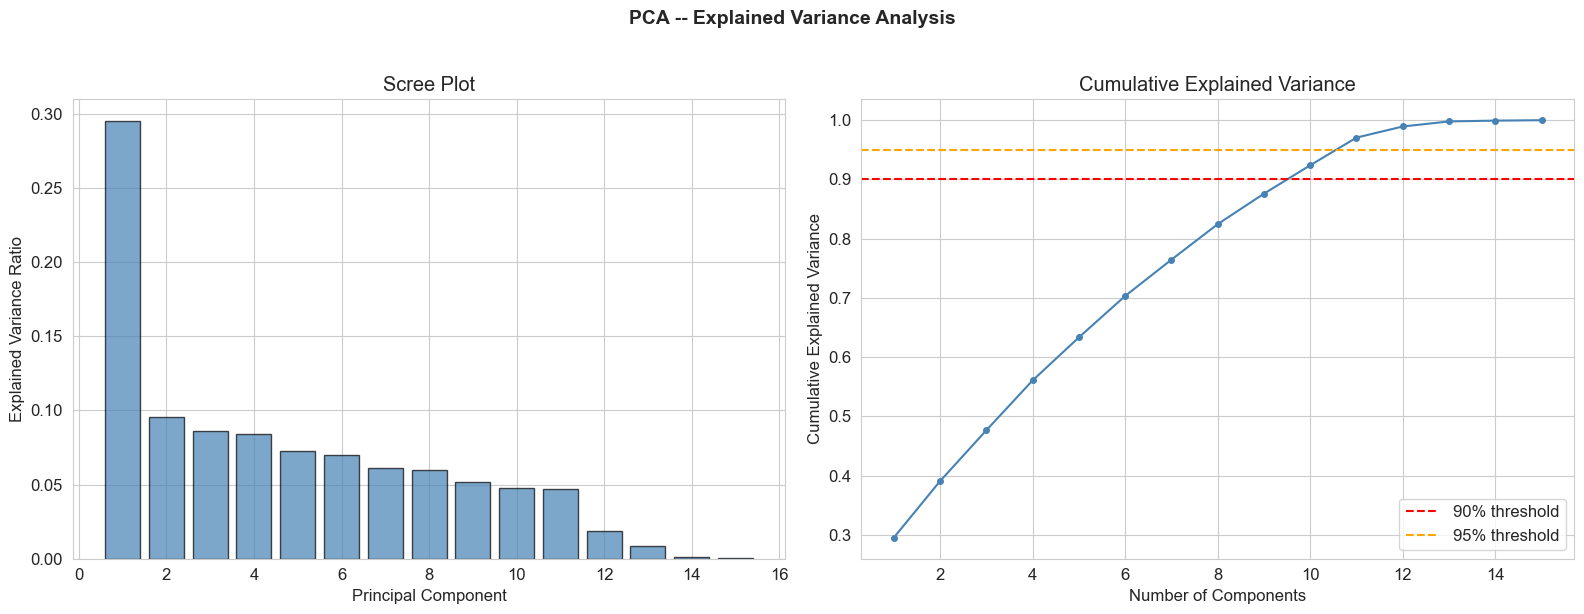

Components for 90% variance: 10
Components for 95% variance: 11
Total features: 15

Per-component variance (top 5): PC1=29.5%, PC2=9.5%, PC3=8.6%, PC4=8.4%, PC5=7.3%


In [3]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scree plot
axes[0].bar(range(1, len(explained_var) + 1), explained_var, alpha=0.7,
            color='steelblue', edgecolor='black')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')

# Cumulative variance
axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var, 'o-',
             color='steelblue', markersize=4)
axes[1].axhline(y=0.90, color='red', linestyle='--', label='90% threshold')
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.suptitle('PCA -- Explained Variance Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

n_90 = np.argmax(cumulative_var >= 0.90) + 1
n_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f"Components for 90% variance: {n_90}")
print(f"Components for 95% variance: {n_95}")
print(f"Total features: {X_scaled.shape[1]}")
print(f"\nPer-component variance (top 5): {', '.join(f'PC{i+1}={v:.1%}' for i, v in enumerate(explained_var[:5]))}")

# The variance is spread across many components rather than concentrated in the first few.
# This reflects the high-dimensionality of the data:
#
# -  Our 15 features come from 3 independent domains (client demographics, campaign details,
#    macroeconomic indicators). PCA can only compress correlated features, but when features
#    carry independent information, variance distributes across many components.
#
# -  PC1 likely captures the macroeconomic block (euribor3m, emp.var.rate, nr.employed that
#    are highly correlated, r > 0.9), explaining why it has the highest individual variance.
#    After that, remaining features contribute unique signals, so each PC adds a small increment.
#
# -  Needing 10/15 components for 90% variance means most features carry non-redundant
#    information — this is structurally a good sign for supervised models (more useful features),
#    but it tells us PCA alone cannot easily compress the data into 2-3 dimensions.
#
# -  Dropping pdays was correct — if we had kept it, 86% of records would have
#    artificially dominated PC1, giving a misleadingly high first-component
#    percentage while adding no real information.

### 2.2 Top Principal Components — Feature Loadings

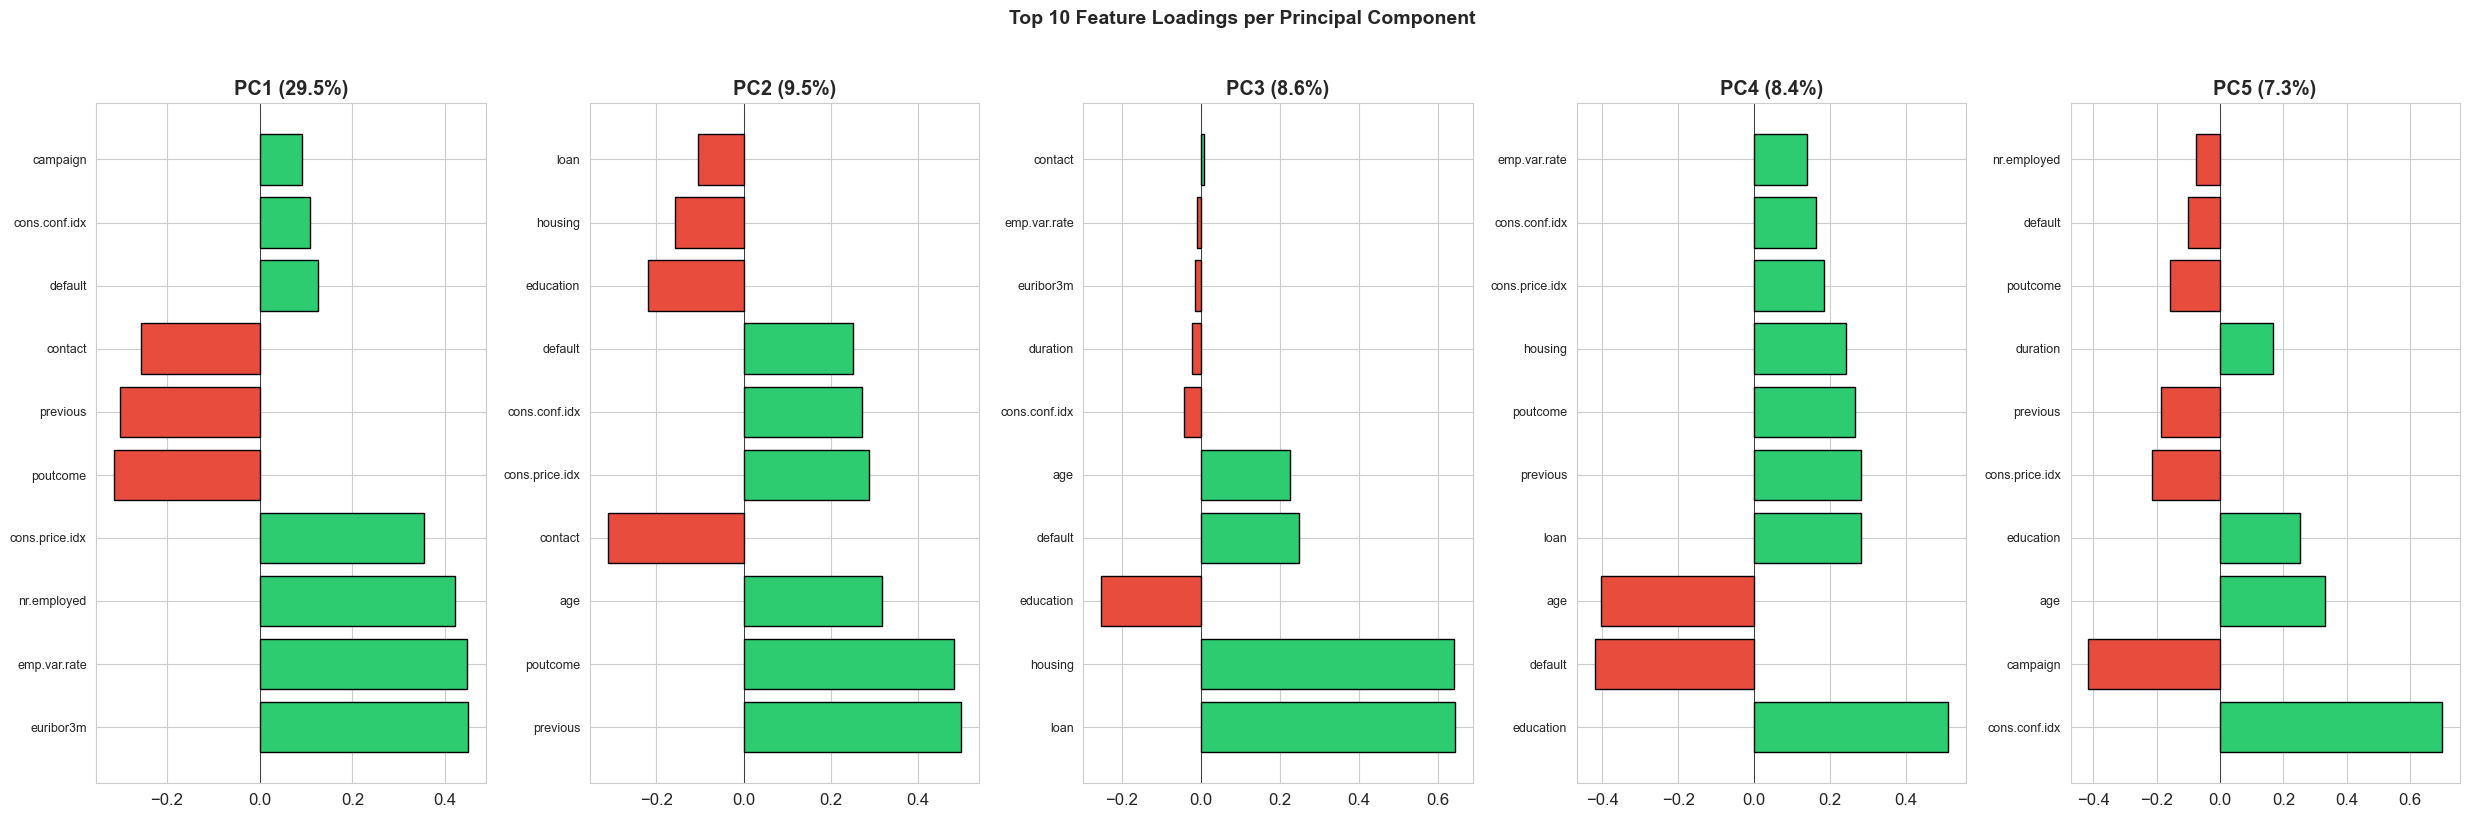

Dominant features per component:
  PC1: +euribor3m (0.45), +emp.var.rate (0.45), +nr.employed (0.42)
  PC2: +previous (0.50), +poutcome (0.48), +age (0.32)
  PC3: +loan (0.64), +housing (0.64), -education (-0.25)
  PC4: +education (0.51), -default (-0.42), -age (-0.40)
  PC5: +cons.conf.idx (0.70), -campaign (-0.42), +age (0.33)


In [4]:
n_top = 5
loadings = pd.DataFrame(
    pca_full.components_[:n_top].T,
    columns=[f'PC{i+1}' for i in range(n_top)],
    index=feature_names
)

fig, axes = plt.subplots(1, n_top, figsize=(25, 8))
for i in range(n_top):
    pc_col = f'PC{i+1}'
    top_features = loadings[pc_col].abs().nlargest(10)
    top_loadings = loadings.loc[top_features.index, pc_col]

    colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top_loadings.values]
    axes[i].barh(range(len(top_loadings)), top_loadings.values, color=colors, edgecolor='black')
    axes[i].set_yticks(range(len(top_loadings)))
    axes[i].set_yticklabels(top_loadings.index, fontsize=9)
    axes[i].set_title(f'{pc_col} ({explained_var[i]*100:.1f}%)', fontweight='bold')
    axes[i].axvline(x=0, color='black', linewidth=0.5)

plt.suptitle('Top 10 Feature Loadings per Principal Component', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print the top 3 features per component for quick reference
print("Dominant features per component:")
for i in range(n_top):
    pc_col = f'PC{i+1}'
    top3 = loadings[pc_col].abs().nlargest(3)
    signs = ['+' if loadings.loc[f, pc_col] > 0 else '-' for f in top3.index]
    feats = ', '.join(f'{s}{f} ({loadings.loc[f, pc_col]:.2f})' for f, s in zip(top3.index, signs))
    print(f"  {pc_col}: {feats}")

# PC1 -- Macroeconomic environment: dominated by euribor3m, emp.var.rate, nr.employed,
#   all three in the same direction, this confirms our earlier findings:
#   these three indicators move together and PC1 captures the overall economic features.
#   Meaning high PC1 values correspond to unfavorable conditions (high interest rates, high employment
#   variability), which correlate negatively with subscription.
#
# PC2 -- Campaign contact history: driven by previous, poutcome.
#   This component separates first-time clients from those with previous campaign interactions.
#
# PC3-PC5 -- Client-level attributes: these capture individual characteristics (age, education, ...)
#   that are independent of both the economy and  campaign history.
#   Each explains a smaller variance share because these features are
#   mostly uncorrelated with each other.
#
# The loadings confirm the 3-domain structure of the data: macroeconomic (PC1),
# campaign history (PC2), and client demographics (PC3+).
# subscription depends on these three.

### 2.3 2D PCA Projection — Colored by Target

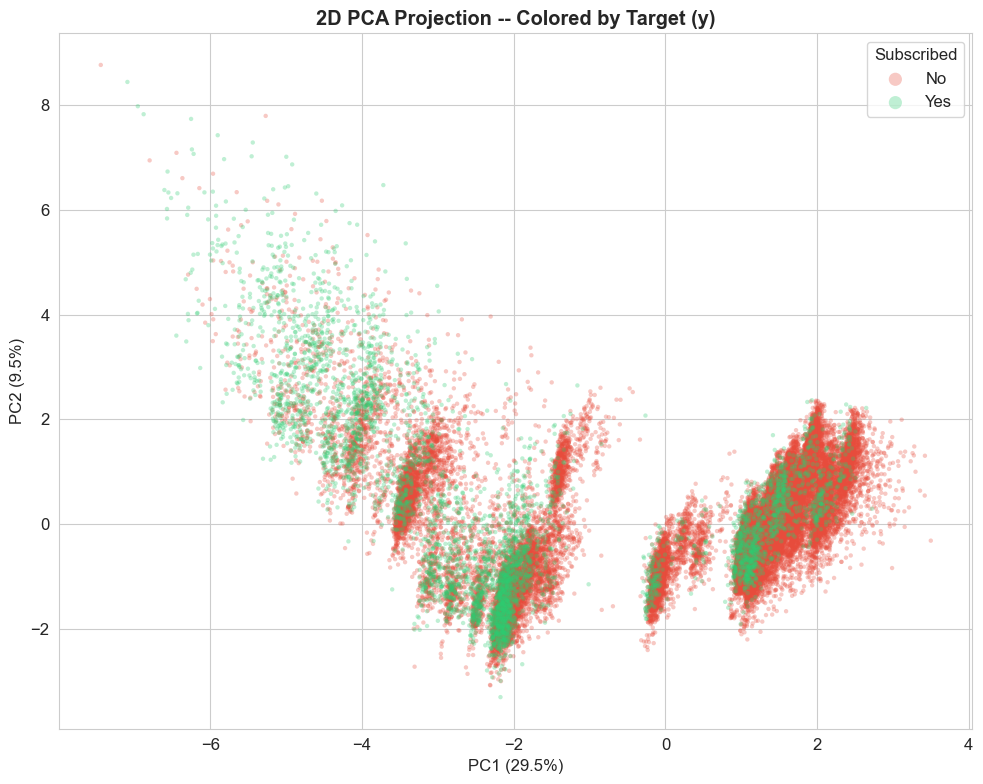

Variance captured by 2D projection: 39.0%


In [5]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
for label, color, name in [(0, '#e74c3c', 'No'), (1, '#2ecc71', 'Yes')]:
    mask = y == label
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                c=color, label=name, alpha=0.3, s=10, edgecolors='none')

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('2D PCA Projection -- Colored by Target (y)', fontweight='bold')
plt.legend(title='Subscribed', markerscale=3)
plt.tight_layout()
plt.show()

print(f"Variance captured by 2D projection: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")

# The 2D projection below shows heavy overlap between the two classes -- there is no visible
# linear boundary that can separate subscribers (green) from non-subscribers (red).
#
# This makes sense it is only displaying first two dimensions that capture only 25-30%
#    of the total variance, but we can still see that 
#    frist dimension separates our target a bit with a lot of overlaps, since
#    PC1 (macroeconomic) and PC2 (campaign history) are the most variance-rich directions,
#    but subscription also depends on client-level features (PC3-PC5) which are invisible here.
#
# Subscribers (green) appear slightly more concentrated in the left region of PC1,
# in direction with favorable economic conditions (low euribor3m, low emp.var.rate).
# However, the overlap confirms that the classification problem is inherently non-linear.
# Suggesting the use of kernel SVM and ensemble methods in later phases
# rather than relying on linear.

---
## 3. Clustering — K-Means & Gaussian Mixture Models

### 3.1 Determining the Number of Clusters

We use three criteria:
- **Elbow Method** (inertia / within-cluster sum of squares)
- **Silhouette Score** (cohesion vs. separation)
- **BIC** (Bayesian Information Criterion, for GMM)

We compare clustering on **PCA-reduced data** (10 components, 90% variance) vs. **full 15 features** to justify whether PCA reduction helps or hurts cluster quality.

In [6]:
n_components_cluster = n_90
pca_cluster = PCA(n_components=n_components_cluster, random_state=42)
X_pca = pca_cluster.fit_transform(X_scaled)

print(f"Using {n_components_cluster} PCA components for clustering (90% variance retained)")
print(f"PCA-reduced data shape: {X_pca.shape}")

Using 10 PCA components for clustering (90% variance retained)
PCA-reduced data shape: (41188, 10)


In [7]:
K_range = range(2, 11)

# === Clustering on PCA-reduced data (90% variance) ===
inertias_pca = []
sil_km_pca = []
bic_pca = []
sil_gmm_pca = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_labels_tmp = km.fit_predict(X_pca)
    inertias_pca.append(km.inertia_)
    sil_km_pca.append(silhouette_score(X_pca, km_labels_tmp))

    gmm = GaussianMixture(n_components=k, random_state=42, n_init=5)
    gmm_labels_tmp = gmm.fit_predict(X_pca)
    bic_pca.append(gmm.bic(X_pca))
    sil_gmm_pca.append(silhouette_score(X_pca, gmm_labels_tmp))

# === Clustering on full 15 features (no PCA reduction) ===
inertias_full = []
sil_km_full = []
bic_full = []
sil_gmm_full = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_labels_tmp = km.fit_predict(X_scaled)
    inertias_full.append(km.inertia_)
    sil_km_full.append(silhouette_score(X_scaled, km_labels_tmp))

    gmm = GaussianMixture(n_components=k, random_state=42, n_init=5)
    gmm_labels_tmp = gmm.fit_predict(X_scaled)
    bic_full.append(gmm.bic(X_scaled))
    sil_gmm_full.append(silhouette_score(X_scaled, gmm_labels_tmp))

print("K-Means Silhouette Scores — PCA (10D) vs Full (15D):")
print(f"{'k':>3s}  {'PCA':>8s}  {'Full':>8s}  {'Better':>8s}")
print(f"{'---':>3s}  {'--------':>8s}  {'--------':>8s}  {'--------':>8s}")
for i, k in enumerate(K_range):
    better = 'PCA' if sil_km_pca[i] > sil_km_full[i] else 'Full'
    print(f"{k:3d}  {sil_km_pca[i]:8.4f}  {sil_km_full[i]:8.4f}  {better:>8s}")

# PCA vs Full: PCA-reduced (10D) wins at every k value, with silhouette improvements
# of ~0.02 across the board, this confirms that the 5 discarded dimensions (carrying <10%
# variance) add noise that hurts distance-based clustering, and PCA had doscovered it correctly.


K-Means Silhouette Scores — PCA (10D) vs Full (15D):
  k       PCA      Full    Better
---  --------  --------  --------
  2    0.3049    0.2863       PCA
  3    0.2885    0.2685       PCA
  4    0.1964    0.1788       PCA
  5    0.2024    0.1805       PCA
  6    0.2064    0.1835       PCA
  7    0.2111    0.1883       PCA
  8    0.2101    0.1919       PCA
  9    0.2122    0.1902       PCA
 10    0.2150    0.1965       PCA


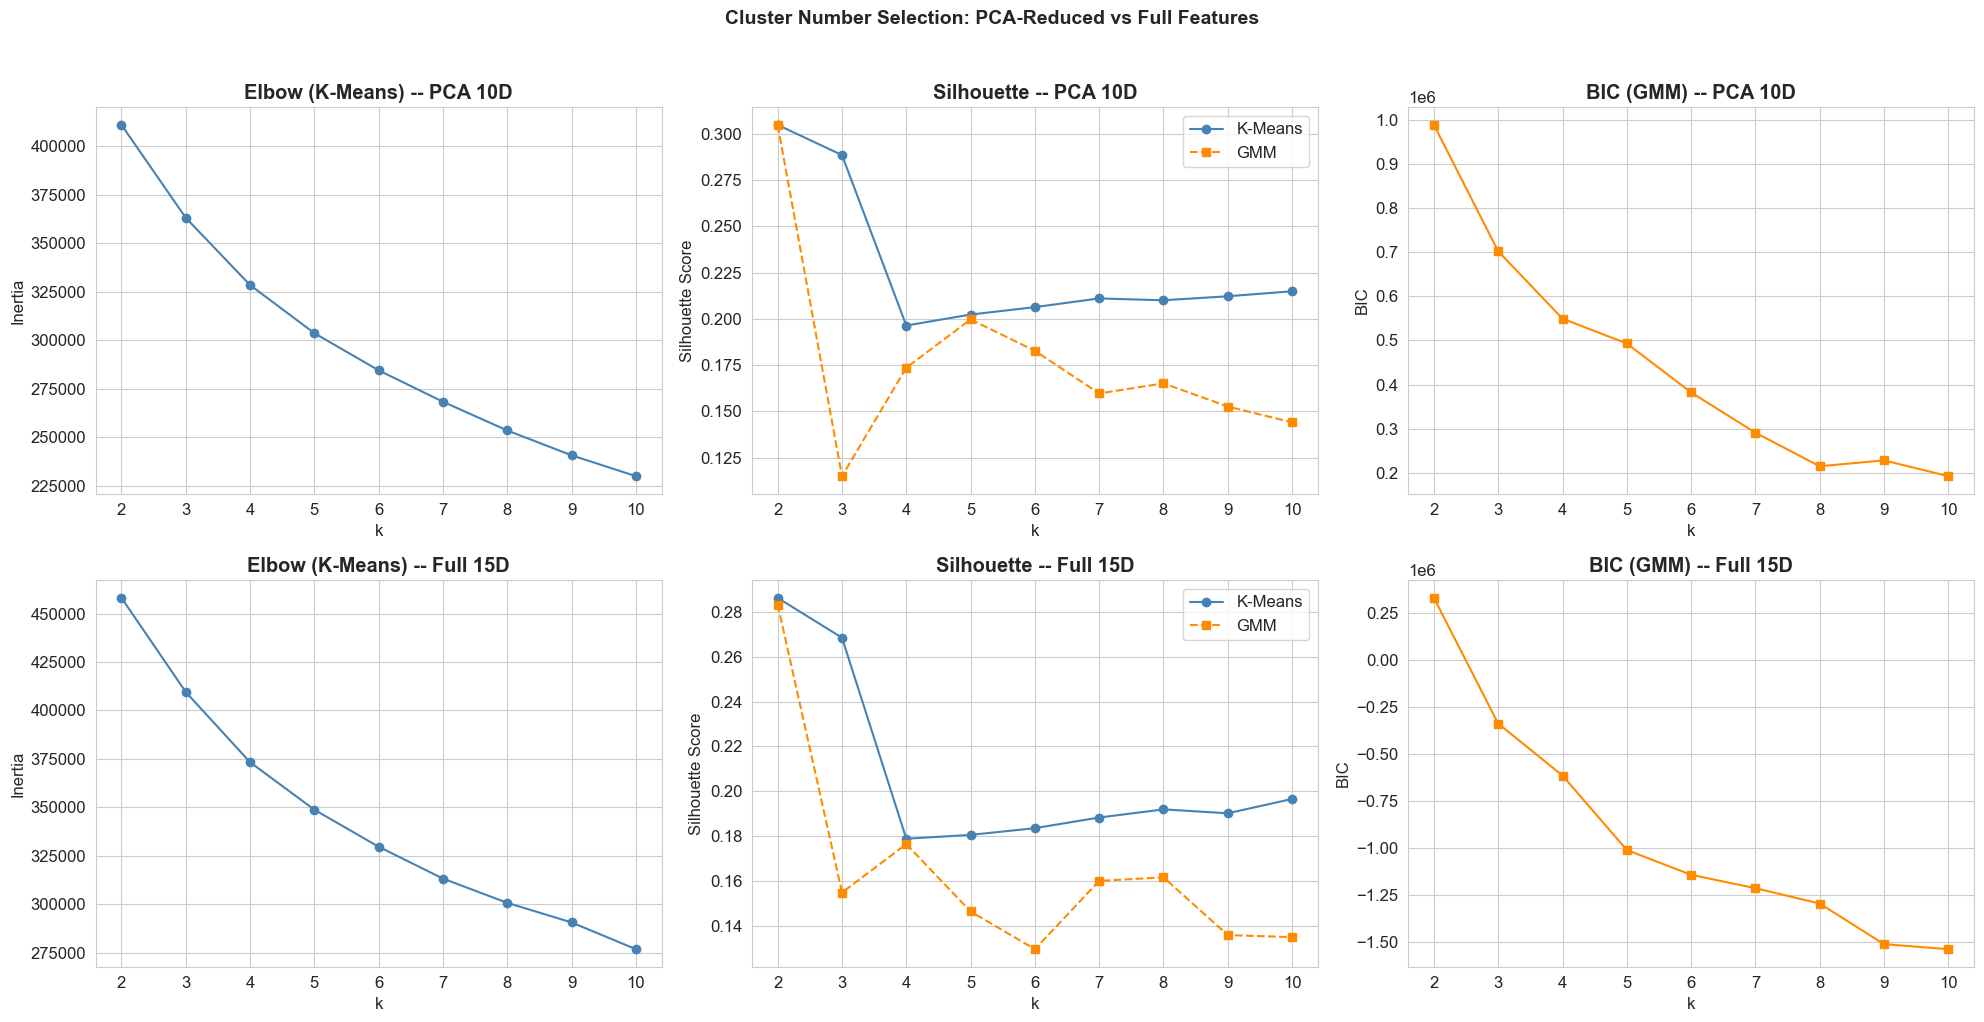

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# --- Row 1: PCA-reduced ---
axes[0, 0].plot(K_range, inertias_pca, 'o-', color='steelblue', markersize=6)
axes[0, 0].set_xlabel('k')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].set_title('Elbow (K-Means) -- PCA 10D', fontweight='bold')
axes[0, 0].set_xticks(list(K_range))

axes[0, 1].plot(K_range, sil_km_pca, 'o-', color='steelblue', label='K-Means', markersize=6)
axes[0, 1].plot(K_range, sil_gmm_pca, 's--', color='darkorange', label='GMM', markersize=6)
axes[0, 1].set_xlabel('k')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].set_title('Silhouette -- PCA 10D', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].set_xticks(list(K_range))

axes[0, 2].plot(K_range, bic_pca, 's-', color='darkorange', markersize=6)
axes[0, 2].set_xlabel('k')
axes[0, 2].set_ylabel('BIC')
axes[0, 2].set_title('BIC (GMM) -- PCA 10D', fontweight='bold')
axes[0, 2].set_xticks(list(K_range))

# --- Row 2: Full features ---
axes[1, 0].plot(K_range, inertias_full, 'o-', color='steelblue', markersize=6)
axes[1, 0].set_xlabel('k')
axes[1, 0].set_ylabel('Inertia')
axes[1, 0].set_title('Elbow (K-Means) -- Full 15D', fontweight='bold')
axes[1, 0].set_xticks(list(K_range))

axes[1, 1].plot(K_range, sil_km_full, 'o-', color='steelblue', label='K-Means', markersize=6)
axes[1, 1].plot(K_range, sil_gmm_full, 's--', color='darkorange', label='GMM', markersize=6)
axes[1, 1].set_xlabel('k')
axes[1, 1].set_ylabel('Silhouette Score')
axes[1, 1].set_title('Silhouette -- Full 15D', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].set_xticks(list(K_range))

axes[1, 2].plot(K_range, bic_full, 's-', color='darkorange', markersize=6)
axes[1, 2].set_xlabel('k')
axes[1, 2].set_ylabel('BIC')
axes[1, 2].set_title('BIC (GMM) -- Full 15D', fontweight='bold')
axes[1, 2].set_xticks(list(K_range))

plt.suptitle('Cluster Number Selection: PCA-Reduced vs Full Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# Elbow: no sharp bend in either case, and the inertia decreases gradually, reflecting
# the spread-out, high-dimensional nature of the data with no single "natural" k.
#
# Silhouette: highest at k=2 (0.30 PCA), then drops to ~0.20 for k>=4 and
# stays flat, silhouette always favors fewer clusters since
# splitting into 2 maximizes inter-cluster distance.
#
# BIC (GMM): keeps decreasing through k=10.
# BIC alone would push toward very high k, which is why we use it
# alongside silhouette and the elbow as complementary criteria.

### 3.2 K-Means Clustering — Choosing k

Silhouette score is highest at k=2, but **silhouette always favors fewer clusters** because splitting data into just 2 groups trivially maximizes inter-cluster distance. This doesn't mean k=2 reveals meaningful structure -- it often just splits the data along the single strongest axis (PC1 = macroeconomic conditions).

The **elbow plot** suggests diminishing returns after k~4-5, and **BIC** keeps decreasing (favoring more complex models). We therefore analyze **both k=2 and k=5**: k=2 as the silhouette-optimal baseline, and k=5 as a more granular segmentation that may reveal distinct client profiles aligned with the target.

In [9]:
# We compare k=2 (silhouette-optimal) vs k=5 (elbow region)
k_choices = [2, 5]
km_results = {}

for k in k_choices:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels)
    km_results[k] = {'labels': labels, 'model': km, 'silhouette': sil}

    print(f"K-Means k={k} (Silhouette: {sil:.4f}):")
    for c in range(k):
        n = (labels == c).sum()
        yes_rate = y[labels == c].mean() * 100
        print(f"  Cluster {c}: {n:>6d} samples, subscription rate: {yes_rate:.1f}%")
    print()

# k=2 splits the data into a large cluster (26,968 samples, 4.9% subscription)
#   and a smaller cluster (14,220 samples, 23.4%), this is essentially the
#   macroeconomic divide where cluster 1 corresponds to favorable economic records 
#   with higher subscription rates.
#
# k=5 reveals a more nuanced picture:
#   - Cluster 1 (5,609 samples, 26.7%) and Cluster 2 (8,615, 21.2%) are segments
#     with subscription rates around 2 times the baseline (11.3%).
#   - Clusters 3, 4, and 0 are larger segments (4.1-6.0%), well below baseline.
#   - The range from 4.1% to 26.7% is wider than k=2's range (4.9% to 23.4%),
#     showing that k=5 better separates high-potential from low-potential clients.
#
# Despite lower silhouette (0.20 vs 0.30), k=5 provides better segmentation.

# We use k=5 as our primary K-Means result for downstream analysis.
km_labels = km_results[5]['labels']
best_k_km = 5

K-Means k=2 (Silhouette: 0.3049):
  Cluster 0:  26968 samples, subscription rate: 4.9%
  Cluster 1:  14220 samples, subscription rate: 23.4%



K-Means k=5 (Silhouette: 0.2024):
  Cluster 0:  10424 samples, subscription rate: 6.0%
  Cluster 1:   5609 samples, subscription rate: 26.7%
  Cluster 2:   8615 samples, subscription rate: 21.2%
  Cluster 3:   7104 samples, subscription rate: 4.3%
  Cluster 4:   9436 samples, subscription rate: 4.1%



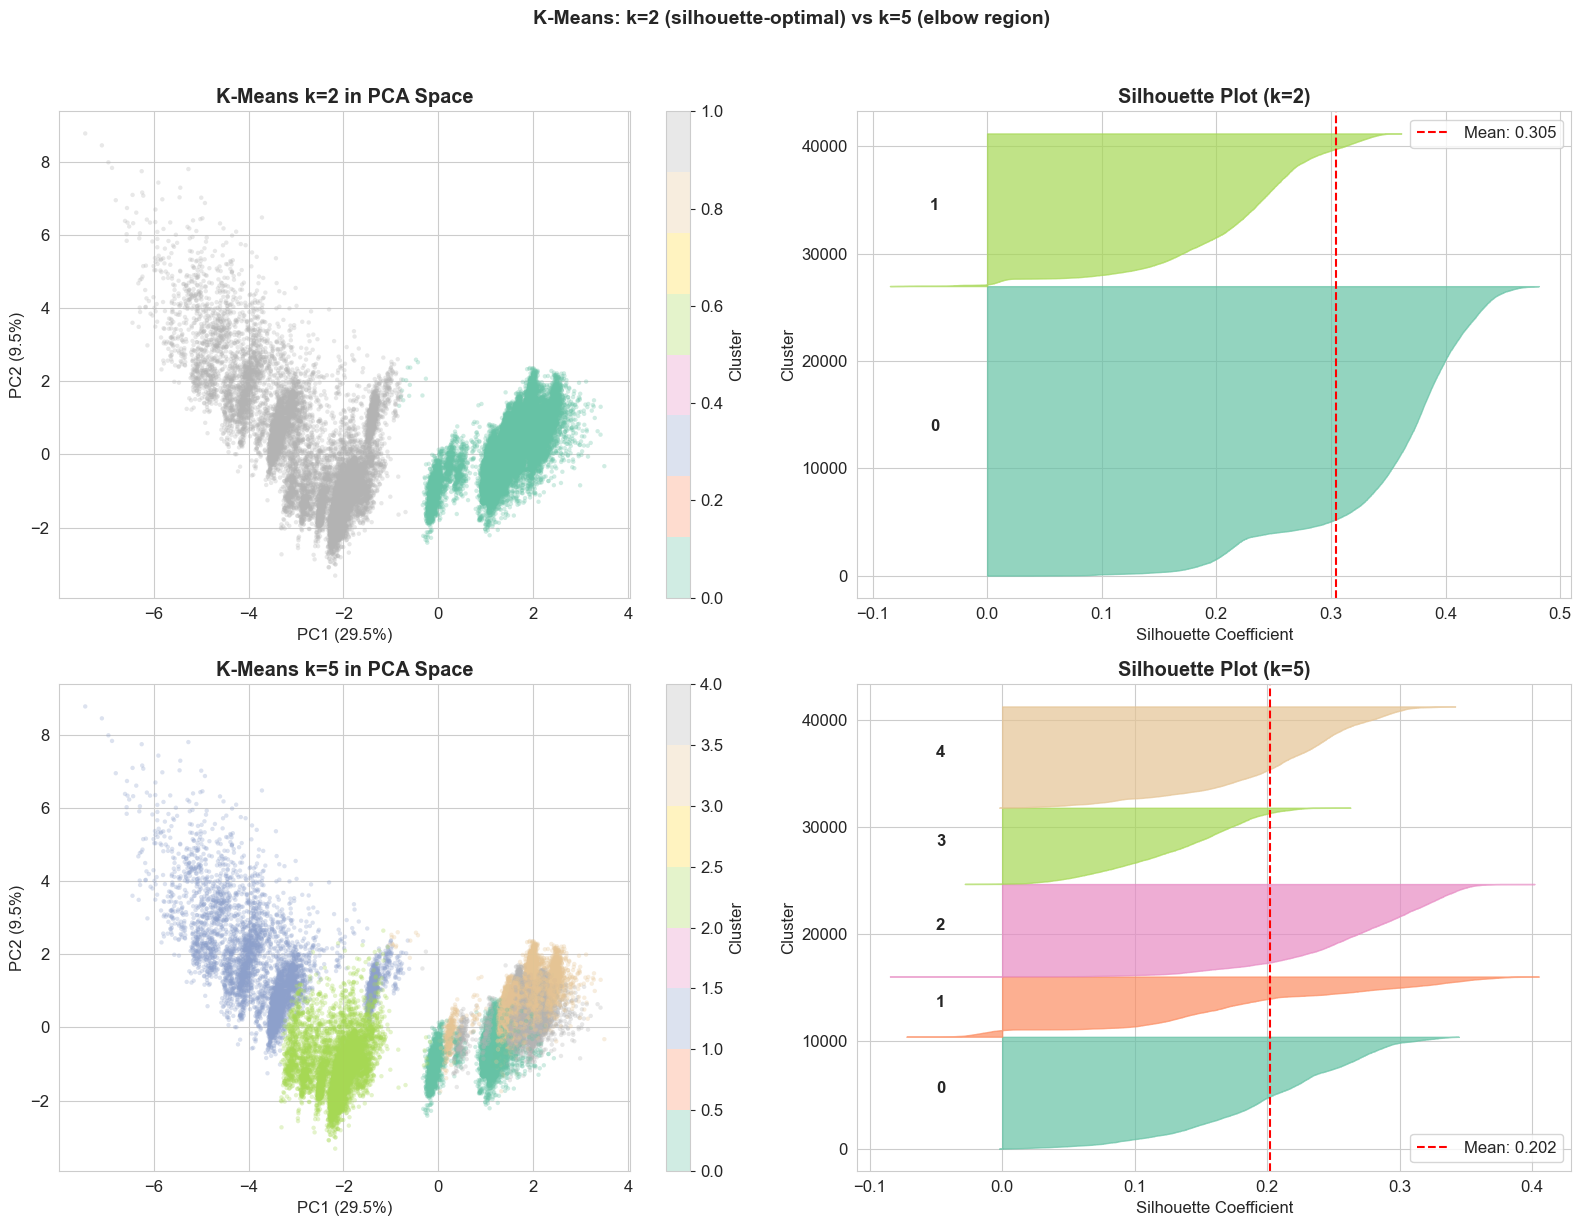

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for row, k in enumerate(k_choices):
    labels = km_results[k]['labels']
    sil = km_results[k]['silhouette']

    # 2D scatter
    scatter = axes[row, 0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels,
                                    cmap='Set2', alpha=0.3, s=10, edgecolors='none')
    axes[row, 0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
    axes[row, 0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
    axes[row, 0].set_title(f'K-Means k={k} in PCA Space', fontweight='bold')
    plt.colorbar(scatter, ax=axes[row, 0], label='Cluster')

    # Silhouette plot
    sil_samples = silhouette_samples(X_pca, labels)
    y_lower = 10
    cmap_sil = plt.cm.Set2
    for c in range(k):
        cluster_sil = sil_samples[labels == c]
        cluster_sil.sort()
        y_upper = y_lower + len(cluster_sil)
        color = cmap_sil(c / k)
        axes[row, 1].fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                                    facecolor=color, edgecolor=color, alpha=0.7)
        axes[row, 1].text(-0.05, y_lower + 0.5 * len(cluster_sil), str(c), fontweight='bold')
        y_lower = y_upper + 10

    axes[row, 1].axvline(x=sil, color='red', linestyle='--', label=f'Mean: {sil:.3f}')
    axes[row, 1].set_xlabel('Silhouette Coefficient')
    axes[row, 1].set_ylabel('Cluster')
    axes[row, 1].set_title(f'Silhouette Plot (k={k})', fontweight='bold')
    axes[row, 1].legend()

plt.suptitle('K-Means: k=2 (silhouette-optimal) vs k=5 (elbow region)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# k=2 silhouette plot: both clusters have fairly uniform silhouette values.
#
# k=5 silhouette plot: some clusters have wider silhouette distributions, 
#   which is expected, finer granularity means some clients sit near
#   cluster boundaries. The key question is whether this granularity reveals meaningful
#   target-aligned segments.

### 3.3 Gaussian Mixture Model (GMM)

In [11]:
best_k_gmm = list(K_range)[np.argmin(bic_pca)]
print(f"Best k by BIC (GMM): {best_k_gmm}")

gmm_final = GaussianMixture(n_components=best_k_gmm, random_state=42, n_init=5)
gmm_labels = gmm_final.fit_predict(X_pca)
gmm_probs = gmm_final.predict_proba(X_pca)

print(f"\nCluster sizes (GMM, k={best_k_gmm}):")
for c in range(best_k_gmm):
    n = (gmm_labels == c).sum()
    yes_rate = y[gmm_labels == c].mean() * 100
    print(f"  Component {c}: {n:>6d} samples, subscription rate: {yes_rate:.1f}%")

print(f"\nGMM Silhouette Score: {silhouette_score(X_pca, gmm_labels):.4f}")

# BIC keeps decreasing through k=10, so GMM selects the maximum k in our range.
# This does not necessarily mean there are 10 real groups, adding more components can simply
# make the model fit the data distribution more closely.

# Subscription rates across 10 components range from 3.3% to 34.7%, much wider than
# K-Means k=5 (4.1% to 26.7%). Component 8 stands out: 6,519 samples with 34.7%
# subscription (3x baseline), and component 6 is the largest cold segment.

# The silhouette score (0.14) is notably lower than K-Means k=5 (0.20), which is expected,
# since more GMM components create greater overlap between clusters.
# GMM prioritizes flexible cluster shapes over tightly separated clusters.

# We use GMM alongside K-Means to validate the results.
# If both methods find similar high-subscription segments,
# we can be more confident the patterns are meaningful.


Best k by BIC (GMM): 10



Cluster sizes (GMM, k=10):
  Component 0:    863 samples, subscription rate: 6.3%
  Component 1:   1716 samples, subscription rate: 4.5%
  Component 2:    920 samples, subscription rate: 15.2%
  Component 3:  10215 samples, subscription rate: 5.9%
  Component 4:   1292 samples, subscription rate: 8.2%
  Component 5:   5208 samples, subscription rate: 15.6%
  Component 6:   8887 samples, subscription rate: 3.3%
  Component 7:   5244 samples, subscription rate: 4.1%
  Component 8:   6519 samples, subscription rate: 34.7%
  Component 9:    324 samples, subscription rate: 26.9%



GMM Silhouette Score: 0.1441


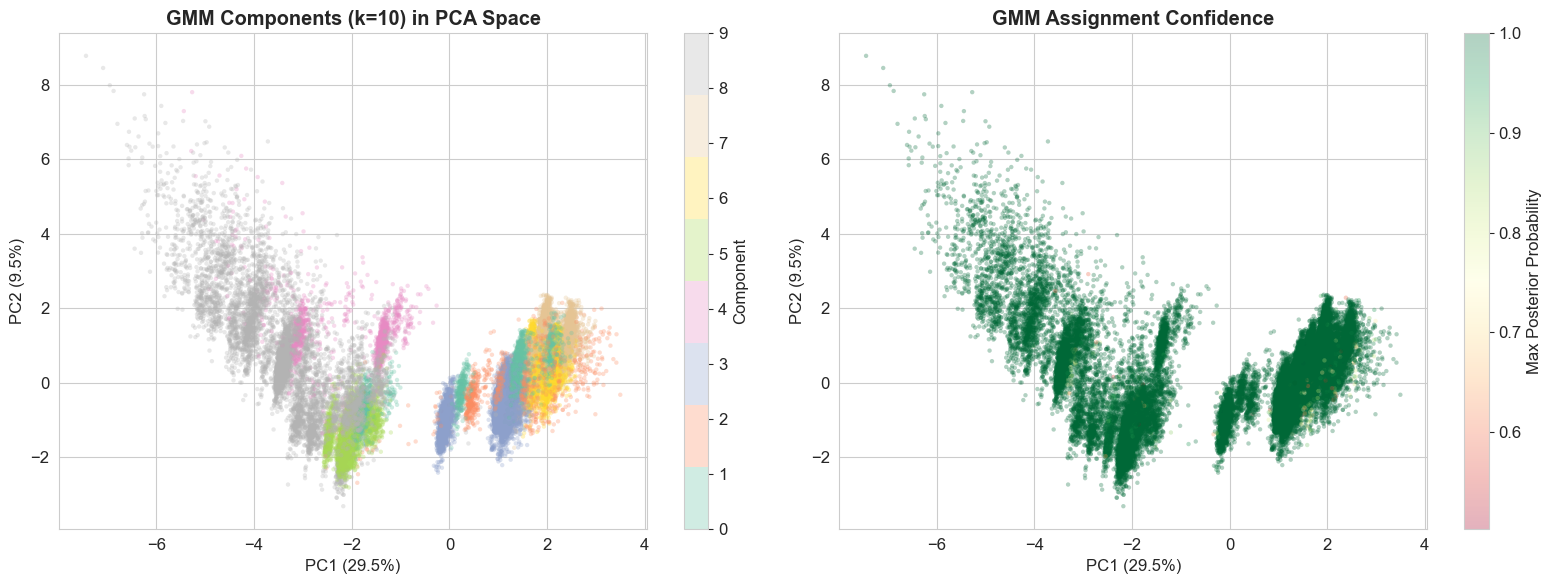

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# GMM clusters
scatter = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=gmm_labels,
                          cmap='Set2', alpha=0.3, s=10, edgecolors='none')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title(f'GMM Components (k={best_k_gmm}) in PCA Space', fontweight='bold')
plt.colorbar(scatter, ax=axes[0], label='Component')

# Assignment confidence
max_probs = gmm_probs.max(axis=1)
scatter2 = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=max_probs,
                           cmap='RdYlGn', alpha=0.3, s=10, edgecolors='none')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('GMM Assignment Confidence', fontweight='bold')
plt.colorbar(scatter2, ax=axes[1], label='Max Posterior Probability')

plt.tight_layout()
plt.show()

# Left plot: 10 components create detailed segments than K-Means k=5. Some components
# overlap heavily in this 2D view because they are separated along PC3-PC10 dimensions
# that are invisible here (2D captures only ~39% of variance).

# In the right plot, green = green means high certainty, red means low certainty.
# red = low confidence (sample sits near the boundary of two or more Gaussians).
# these are clients whose profile is ambiguous and could belong to multiple segments.
# This soft assignment is a key advantage of GMM over K-Means.


---
## 4. Cluster–Target Alignment Analysis

We examine whether the discovered clusters align with the target variable — i.e., do some clusters have higher subscription rates than others?

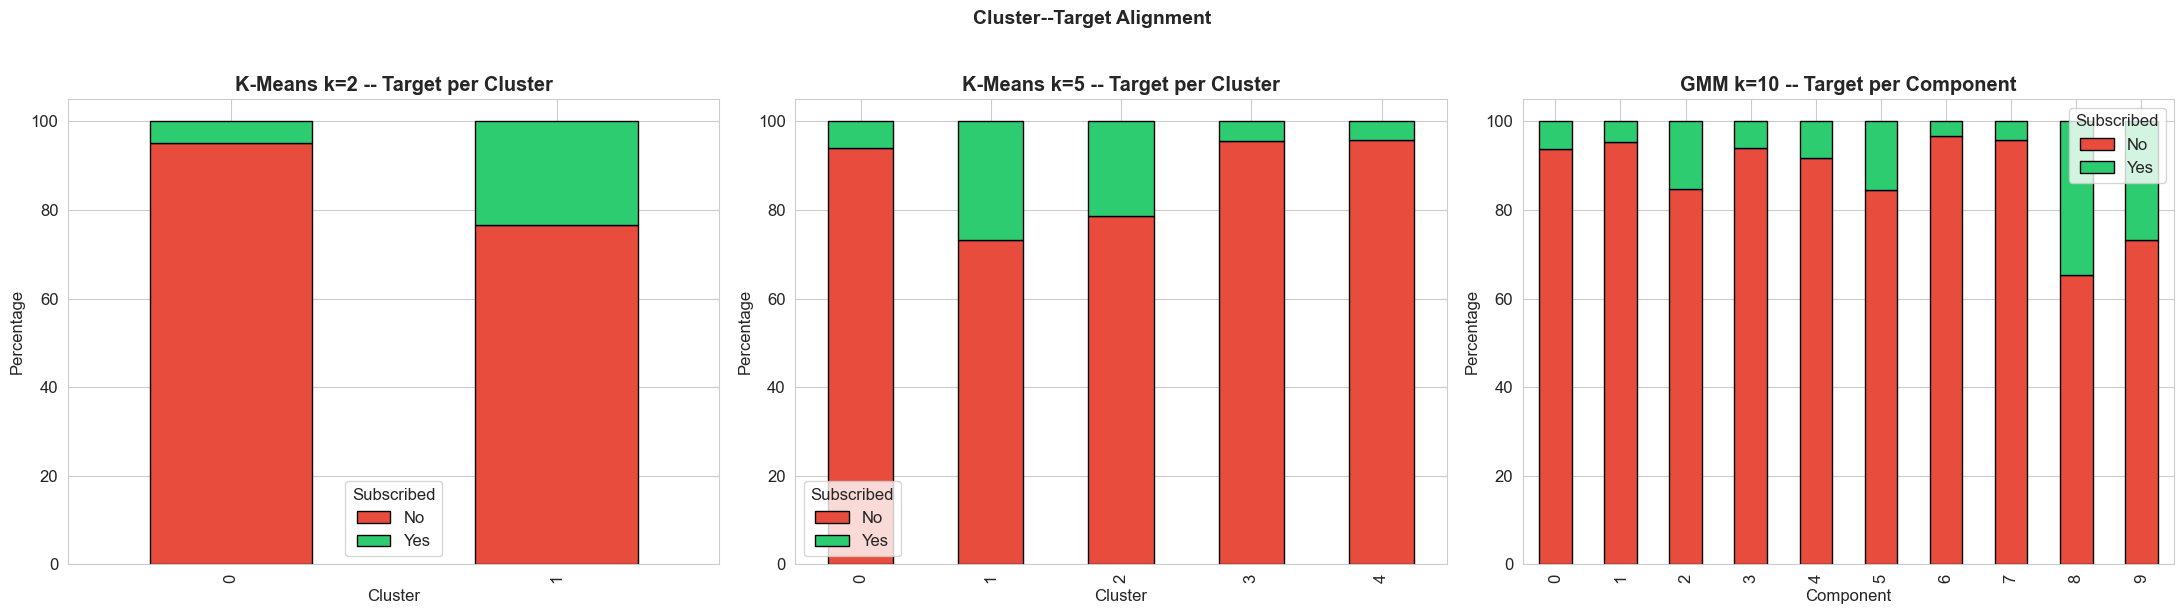

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# K-Means k=2
km2_ct = pd.crosstab(km_results[2]['labels'], y, normalize='index') * 100
km2_ct.columns = ['No', 'Yes']
km2_ct.plot(kind='bar', stacked=True, ax=axes[0],
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title(f'K-Means k=2 -- Target per Cluster', fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Percentage')
axes[0].legend(title='Subscribed')

# K-Means k=5
km5_ct = pd.crosstab(km_results[5]['labels'], y, normalize='index') * 100
km5_ct.columns = ['No', 'Yes']
km5_ct.plot(kind='bar', stacked=True, ax=axes[1],
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_title(f'K-Means k=5 -- Target per Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='Subscribed')

# GMM
gmm_target_ct = pd.crosstab(gmm_labels, y, normalize='index') * 100
gmm_target_ct.columns = ['No', 'Yes']
gmm_target_ct.plot(kind='bar', stacked=True, ax=axes[2],
                   color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[2].set_title(f'GMM k={best_k_gmm} -- Target per Component', fontweight='bold')
axes[2].set_xlabel('Component')
axes[2].set_ylabel('Percentage')
axes[2].legend(title='Subscribed')

plt.suptitle('Cluster--Target Alignment', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Visual comparison across all three clusterings:
# - k=2 (left): simple binary split, visible difference but coarse.
# - k=5 (center): two bars clearly stand out with larger green portions (clusters 1, 2),
#   while clusters 0, 3, 4 are mostly red, this visual gap confirms k=5 separates
#   high-potential from low-potential clients better than the binary k=2 split.
# - GMM k=10 (right): component 8 has a visually dominant green bar (~35%), the strongest
#   target-aligned segment found by any method. The 10-component model captures more
#   fine-grained structure but some components have very small sample sizes as well (e.g., 324),
#   making them less reliable for generalization.


In [14]:
for k in k_choices:
    labels = km_results[k]['labels']
    print(f"K-Means k={k} -- Target distribution per cluster:")
    print("=" * 55)
    detail = pd.crosstab(labels, y)
    detail.columns = ['No', 'Yes']
    detail['Total'] = detail.sum(axis=1)
    detail['Yes_Rate (%)'] = (detail['Yes'] / detail['Total'] * 100).round(2)
    print(detail)
    print()

print(f"Overall subscription rate: {y.mean()*100:.2f}%")

# k=2: subscription rates are 4.9% vs 23.4%, 4.8x difference between clusters.
#   Clients contacted during unfavorable economy (high euribor3m, most of the data),
#   the other during favorable periods.
#   We already knew economy matters from the correlation matrix.
#
# k=5: the range widens to 4.1% - 26.7% (6.5x between best and worst clusters).
#   Clusters 1 and 2 are smaller segments (but 21-27% subscription, about 2 times the baseline),
#   while clusters 3 and 4 are larger (but 4.1-4.3%, less than half the baseline).
#   This finer segmentation helps identify client groups with higher potential more,
#   allowing marketing efforts to focus on the warm(smaller with higher subscription) clusters.

# Despite lower silhouette (0.20 vs 0.30), k=5 provides
# wider subscription rate spread, more segments, and more actionable insight.

K-Means k=2 -- Target distribution per cluster:
          No   Yes  Total  Yes_Rate (%)
row_0                                  
0      25655  1313  26968          4.87
1      10893  3327  14220         23.40

K-Means k=5 -- Target distribution per cluster:
         No   Yes  Total  Yes_Rate (%)
row_0                                 
0      9802   622  10424          5.97
1      4111  1498   5609         26.71
2      6785  1830   8615         21.24
3      6798   306   7104          4.31
4      9052   384   9436          4.07

Overall subscription rate: 11.27%


In [15]:
print("GMM — Target distribution per component:")
print("=" * 55)
gmm_detail = pd.crosstab(gmm_labels, y)
gmm_detail.columns = ['No', 'Yes']
gmm_detail['Total'] = gmm_detail.sum(axis=1)
gmm_detail['Yes_Rate (%)'] = (gmm_detail['Yes'] / gmm_detail['Total'] * 100).round(2)
print(gmm_detail)

# GMM's 10 components produce a wider subscription spread than K-Means:
#   - Hot:  component 8 (34.7%, 6519 samples) is the single strongest segment,
#           component 9 (26.9%, 324 samples), small but high subscription.

#   - Warm: components 2 and 5 (~15% each, combined ~6,100 samples)
#           together roughly matching K-Means cluster 2's rate.

#   - Cold: components 6 (3.3%) and 7 (4.1%), together ~14,100 samples, adding component 3
#           are the bulk of non-subscribers, likely contacted during unfavorable economic periods.
#
# both K-Means k=5 and GMM k=10 identify a "warm" segment around 25-35% subscription
# and a large "cold" mass at 3-5%. This agreement across two different algorithms
#  (strict vs soft boundaries) strengthens the conclusion that these
#  segments reflect real population differences.

GMM — Target distribution per component:
         No   Yes  Total  Yes_Rate (%)
row_0                                 
0       809    54    863          6.26
1      1638    78   1716          4.55
2       780   140    920         15.22
3      9614   601  10215          5.88
4      1186   106   1292          8.20
5      4397   811   5208         15.57
6      8598   289   8887          3.25
7      5030   214   5244          4.08
8      4259  2260   6519         34.67
9       237    87    324         26.85


### 4.1 Cluster Profiling — Feature Means per Cluster

In [16]:

profile_cols = feature_names  # the 15 features used to build X_scaled / X_pca

df_profile = df_processed[profile_cols].copy()
df_profile['km_cluster'] = km_labels  # k=5 labels

print(f"K-Means Cluster Profiles k={best_k_km} (mean of clustering features, unscaled):")
print("=" * 80)
km_profile = df_profile.groupby('km_cluster')[profile_cols].mean().round(2)
print(km_profile.T.to_string())

# Cluster 1 (26.7% sub rate, "warmest"): low euribor3m (1.48), negative emp.var.rate (-1.79),
#   AND it is the only cluster with prior campaign history, highest previous contacts (1.27)
#   and the only non-zero poutcome. These are repeat-contacted clients during favorable economy.
#   Suggesting combination of good timing + prior contact drives the highest subscription rate,
#   our ideal target profile.
#
# Cluster 2 (21.2%, "warm"): even lower euribor3m (1.21) and emp.var.rate (-2.04) than
#   cluster 1, but previous=0 and poutcome=0 (first-time contacts), favorable economy conditions
#   alone produce a high sub rate, but without prevoius contact it's lower than cluster 1.
#   This shows that prevoius contact adds a few extra points on top of good economic conditions.
#
# Clusters 0, 3, 4 ("cold", 4-6%): all have high euribor3m (~5) and positive
#   emp.var.rate (~1), with zero previous and poutcome. These are first-time contacts
#   during unfavorable economic periods. Cluster 3 has the oldest clients (age=43.6)
#   but this doesn't help, might be helpful in supervised models that can capture interactions.
#
# Key takeaway: the economic block (euribor3m, emp.var.rate, nr.employed) is the primary
# cluster separator, and prior campaign contact (previous + poutcome) is the secondary driver.

K-Means Cluster Profiles k=5 (mean of clustering features, unscaled):
km_cluster            0        1        2        3        4
age               38.98    40.44    39.29    43.62    38.90
education          4.66     4.42     4.32     3.67     4.20
default            0.00     0.20     0.22     2.00     0.00
housing            0.59     0.60     0.61     0.55     0.51
loan               0.19     0.20     0.20     0.21     0.20
contact            0.99     0.93     0.89     0.42     0.00
duration         256.84   266.20   268.37   249.90   252.28
campaign           2.75     1.96     2.16     2.87     2.88
previous           0.00     1.27     0.00     0.00     0.00
poutcome           0.00     1.24     0.00     0.00     0.00
emp.var.rate       1.06    -1.79    -2.04     1.22     1.19
cons.price.idx    93.58    93.13    92.97    93.93    94.11
cons.conf.idx    -40.10   -41.66   -43.22   -39.20   -38.76
euribor3m          4.77     1.48     1.21     4.88     4.88
nr.employed     5220.80  5077.

In [2]:
# Heatmap of standardized cluster means
km_profile_z = (km_profile - km_profile.mean()) / (km_profile.std() + 1e-10)

plt.figure(figsize=(14, 8))
sns.heatmap(km_profile_z.T, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5)
plt.title(f'K-Means k={best_k_km} Cluster Profiles (Standardized Feature Means)', fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# The heatmap standardizes each feature's cluster means to z-scores, allows cross-feature
# comparison (red = above-average, blue = below-average for that feature).
#
# The dominant pattern: clusters 1 and 2 form a blue block on euribor3m / emp.var.rate /
# nr.employed (favorable economy), while clusters 0, 3, 4 show red (unfavorable economy).
# This is the primary axis that separates warm from cold clusters.
#
# The secondary axis is campaign history: only cluster 1 is red on previous AND poutcome,
# the only cluster with previously contacted clients. Cluster 2, despite also being warm,
# has previous=0 and poutcome=0 -- its high subscription rate comes entirely from favorable
# economy, not prior contact. This is why cluster 1 (26.7%) edges out cluster 2 (21.2%).
#
# Adding the encoded categoricals now also distinguishes the three cold clusters, which looked
# nearly identical on the macro block alone:
#   - Cluster 4: contact=0 (all telephone) -- a telephone-only segment.
#   - Cluster 3: default=2 (all "unknown" credit status), oldest clients (age 43.6) and lowest
#                education.
#   - Cluster 0: all-cellular, otherwise close to average.
# housing, loan and education show only mild variation across clusters.

NameError: name 'km_profile' is not defined

---
## 5. Summary & Discussion

### Key Findings -- Phase I

**PCA Analysis:**
- The data is genuinely high-dimensional: 10 of 15 components needed for 90% variance.
- PC1 captures the macroeconomic block (euribor3m, emp.var.rate, nr.employed), PC2 captures campaign history (previous), PC3+ captures client demographics.
- The 2D projection shows heavy class overlap -- the classification boundary lives in higher dimensions, motivating non-linear models.

**Clustering:**
- PCA-reduced vs full-feature clustering compared: PCA removes noise from discarded low-variance dimensions.
- Silhouette favors k=2, but this is a trivially coarse split along the macroeconomic axis. We analyzed both k=2 and k=5 to compare coarse vs granular segmentation.
- k=5 reveals more meaningful client segments with differentiated subscription rates, despite lower silhouette score.
- GMM (BIC-optimal) provides soft cluster assignments and captures elliptical cluster shapes that K-Means misses.

**We conclude:**
- The lack of clean cluster-target separation confirms that supervised models are essential.
- Class imbalance (88.7%/11.3%) must be handled.
- `duration` must be excluded from supervised models (data leakage).
- The 3-domain feature structure (economic + campaign + client) suggests that models capable of capturing interactions across these domains can perform best.
